In [1]:
"""
    File: modello.ipynb
    Author: Andrea Macale
    Date: 2026-03-04

    Description: Notebook per la realizzazione del modello per il suggerimento ed analisi di follow-up clinici

"""

'\n    File: modello.ipynb\n    Author: Andrea Macale\n    Date: 2026-03-04\n\n    Description: Notebook per la realizzazione del modello per il suggerimento ed analisi di follow-up clinici\n\n'

# Parte 0: Importazione delle librerie

In [2]:
%pip install -r requirements.txt -q

Note: you may need to restart the kernel to use updated packages.


## Librerie principali

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

In [3]:
import sys

# Si sposta nella directory principale dello Studio
os.chdir('/teamspace/studios/this_studio')
#path = os.path.expanduser('~/Documenti/Tesi-Magistrale')
#os.chdir(path)
# Aggiunge la directory corrente al PATH per trovare 'src'
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print(f"Directory attuale: {os.getcwd()}")

Directory attuale: /teamspace/studios/this_studio


## Correlazione 

In [4]:
from sklearn.preprocessing import LabelEncoder
import scipy.stats
from scipy.stats import spearmanr

## VIF

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm

## Distribuzione dei dati

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Train

In [7]:
import torch
import torchvision.transforms as T
import torch.nn as nn
from src.train.train import train_modello_visivo, train_modello_clinico
from src.models.DiagnosiIntegrata import DiagnosiIntegrata
from src.train.evaluator import Evaluator
from src.features.RXToraceDataset import RXToraceDataset
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer, util

In [8]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

# Parte 1: Estrazione dei dati

## Aperta dei file del dataset

In [9]:
pos_dataset = os.path.join("data")

In [10]:
file = os.path.join(pos_dataset, "patients.csv")
pazienti = pd.read_csv(file)
pazienti['subject_id'] = pazienti['subject_id'].astype(str)
pazienti.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


In [11]:
file = os.path.join(pos_dataset, "diagnoses_icd.csv")
tipi = {
    'subject_id': str, 
    'hadm_id': str, 
    'icd_code': str, 
    'icd_version': str
}
diagnosi = pd.read_csv(file, dtype=tipi)
diagnosi['icd_version'] = pd.to_numeric(diagnosi['icd_version'], errors='coerce').fillna(0).astype(int)
diagnosi = diagnosi.drop_duplicates()
diagnosi.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


In [12]:
file = os.path.join(pos_dataset, "mimic-cxr-2.0.0-metadata.csv")
metadati = pd.read_csv(file)
metadati['dicom_id'] = metadati['dicom_id'].astype(str)
metadati['subject_id'] = metadati['subject_id'].astype(str)
metadati['study_id'] = metadati['study_id'].astype(str)
metadati.head()

,dicom_id,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,50414267,CHEST (PA AND LAT),PA,3056,2544,21800506,213014.531,CHEST (PA AND LAT),postero-anterior,Erect
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,10000032,50414267,CHEST (PA AND LAT),LATERAL,3056,2544,21800506,213014.531,CHEST (PA AND LAT),lateral,Erect
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,53189527,CHEST (PA AND LAT),PA,3056,2544,21800626,165500.312,CHEST (PA AND LAT),postero-anterior,Erect
3,e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c,10000032,53189527,CHEST (PA AND LAT),LATERAL,3056,2544,21800626,165500.312,CHEST (PA AND LAT),lateral,Erect
4,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,10000032,53911762,CHEST (PORTABLE AP),AP,2705,2539,21800723,80556.875,CHEST (PORTABLE AP),antero-posterior,NaN


In [13]:
file = os.path.join(pos_dataset, "icustays.csv")
visite = pd.read_csv(file)
visite['subject_id'] = metadati['subject_id'].astype(str)
visite.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266
1,10000032,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252
2,10000032,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535
3,10000032,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032
4,10000032,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113


In [14]:
file = os.path.join(pos_dataset, "admissions.csv")
ammissioni = pd.read_csv(file)
ammissioni['subject_id'] = ammissioni['subject_id'].astype(str)
ammissioni

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546023,19999828,25744818,2149-01-08 16:44:00,2149-01-18 17:00:00,NaN,EW EMER.,P13JMH,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,English,SINGLE,WHITE,2149-01-08 09:11:00,2149-01-08 18:12:00,0
546024,19999828,29734428,2147-07-18 16:23:00,2147-08-04 18:10:00,NaN,EW EMER.,P38XL8,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicaid,English,SINGLE,WHITE,2147-07-17 17:18:00,2147-07-18 17:34:00,0
546025,19999840,21033226,2164-09-10 13:47:00,2164-09-17 13:42:00,2164-09-17 13:42:00,EW EMER.,P33612,EMERGENCY ROOM,DIED,Private,English,WIDOWED,WHITE,2164-09-10 11:09:00,2164-09-10 14:46:00,1
546026,19999840,26071774,2164-07-25 00:27:00,2164-07-28 12:15:00,NaN,EW EMER.,P036NA,EMERGENCY ROOM,HOME,Private,English,WIDOWED,WHITE,2164-07-24 21:16:00,2164-07-25 01:20:00,0


In [15]:
lista_immagini = []
ricerca = Path(os.path.join(pos_dataset, "MIMIC_SUPER_RES_24K"))
for file_path in ricerca.rglob('*.jpg'):
    dicom_id = file_path.stem
    lista_immagini.append({'dicom_id': dicom_id, 'path_immagine': str(file_path)})
immagini = pd.DataFrame(lista_immagini)
immagini['path_immagine'] = immagini['path_immagine'].str.replace(str(pos_dataset+"/"), "data/", regex=False) # pulisci il path
immagini['dicom_id'] = immagini['dicom_id'].astype(str)
print(f"{len(immagini)} immagini")
immagini.head()

24000 immagini


,dicom_id,path_immagine
0,a871e82c-88275a72-5c9eff0a-f5855ee5-adebe5ab,data/MIMIC_SUPER_RES_24K/a871e82c-88275a72-5c9...
1,7ead8b45-6419e8af-026c26f4-320a0f1a-35ed5c06,data/MIMIC_SUPER_RES_24K/7ead8b45-6419e8af-026...
2,51e9fa67-b7e8a1c8-e22f6dfc-f300eec6-1d543983,data/MIMIC_SUPER_RES_24K/51e9fa67-b7e8a1c8-e22...
3,9cd67ba1-3fbb8514-de2270f8-61e0296a-002d9bf1,data/MIMIC_SUPER_RES_24K/9cd67ba1-3fbb8514-de2...
4,b1fee7ef-bc3c6a9e-03edf6ed-0e4f1a01-37d6623a,data/MIMIC_SUPER_RES_24K/b1fee7ef-bc3c6a9e-03e...


In [16]:
df_referti = pd.merge(immagini, metadati, on='dicom_id', how='inner')
df_referti

,dicom_id,path_immagine,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning
0,a871e82c-88275a72-5c9eff0a-f5855ee5-adebe5ab,data/MIMIC_SUPER_RES_24K/a871e82c-88275a72-5c9...,15619921,56042987,CHEST (PA AND LAT),AP,3050,2539,21260705,145537.859,CHEST (PA AND LAT),antero-posterior,Erect
1,7ead8b45-6419e8af-026c26f4-320a0f1a-35ed5c06,data/MIMIC_SUPER_RES_24K/7ead8b45-6419e8af-026...,15925803,51425100,CHEST (PORTABLE AP),AP,3056,2544,21590721,80551.531,CHEST (PORTABLE AP),antero-posterior,NaN
2,51e9fa67-b7e8a1c8-e22f6dfc-f300eec6-1d543983,data/MIMIC_SUPER_RES_24K/51e9fa67-b7e8a1c8-e22...,19935359,53980032,CHEST (PA AND LAT),PA,2544,3056,22050320,171452.609,CHEST (PA AND LAT),postero-anterior,Erect
3,9cd67ba1-3fbb8514-de2270f8-61e0296a-002d9bf1,data/MIMIC_SUPER_RES_24K/9cd67ba1-3fbb8514-de2...,15988861,50962072,CHEST (PA AND LAT),AP,2544,3056,21240519,195626.593,CHEST (PA AND LAT),antero-posterior,Erect
4,b1fee7ef-bc3c6a9e-03edf6ed-0e4f1a01-37d6623a,data/MIMIC_SUPER_RES_24K/b1fee7ef-bc3c6a9e-03e...,18993323,53571648,Performed Desc,PA,2021,1771,21891126,112215.000,CHEST (PA AND LAT),postero-anterior,Recumbent
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,9d801ec7-c24f1cfb-6ee86229-7932d77c-777ac363,data/MIMIC_SUPER_RES_24K/9d801ec7-c24f1cfb-6ee...,10921462,54198379,CHEST (PORTABLE AP),AP,2539,2467,21651226,142549.281,CHEST (PORTABLE AP),antero-posterior,Erect
23996,8765d850-aff802c4-b90be8c8-e3c6ed02-20247a48,data/MIMIC_SUPER_RES_24K/8765d850-aff802c4-b90...,17962792,53989748,NaN,PA,2022,2022,21540811,163843.000,CHEST (PA AND LAT),postero-anterior,Erect
23997,9b22faf1-8fb8496b-d8af8681-27e24b3e-6f31dfd9,data/MIMIC_SUPER_RES_24K/9b22faf1-8fb8496b-d8a...,14074396,58876781,NaN,PA,2022,1736,21790917,150343.000,CHEST (PA AND LAT),postero-anterior,Erect
23998,582c4b2a-1336cb18-65827070-f5f7ab58-6fb22c15,data/MIMIC_SUPER_RES_24K/582c4b2a-1336cb18-658...,12837356,50610217,CHEST (PORTABLE AP),AP,2539,3050,21500522,32713.437,CHEST (PORTABLE AP),antero-posterior,NaN


In [17]:
id_necessari = set(df_referti['study_id']) 
ricerca_referti = Path(os.path.join(pos_dataset, "mimic-cxr-reports"))
tutti_i_files_txt = list(ricerca_referti.rglob('*.txt'))
files_filtrati = [f for f in tutti_i_files_txt if f.stem.replace("s", "") in id_necessari]
print(f"Referti totali: {len(tutti_i_files_txt)} | Referti da leggere: {len(files_filtrati)}")

Referti totali: 227835 | Referti da leggere: 23730


In [18]:
def leggi_singolo_referto(file_path):
    """Funzione helper per la lettura parallela"""
    study_id = file_path.stem.replace("s", "")
    with open(file_path, 'r', encoding='utf-8') as f:
        testo = f.read()
    return {'study_id': str(study_id), 'testo_referto': testo}

lista_referti = []
ricerca_referti = Path(os.path.join(pos_dataset, "mimic-cxr-reports"))
files = list(ricerca_referti.rglob('*.txt'))

print(f"Inizio caricamento di {len(files)} file...")

with ThreadPoolExecutor(max_workers=8) as executor:
    lista_referti = list(tqdm(executor.map(leggi_singolo_referto, files_filtrati), total=len(files_filtrati)))

referti = pd.DataFrame(lista_referti)

Inizio caricamento di 227835 file...


  0%|          | 0/23730 [00:00<?, ?it/s]

## Prima pulizia, selezione e join dei dati

In [19]:
dataset = immagini.copy()
dataset = dataset.merge(metadati, on=['dicom_id'], how='inner')
dataset = dataset.merge(referti, on=['study_id'], how='inner')
dataset = dataset.merge(pazienti, on=['subject_id'], how='inner')
ammissioni_uniche = ammissioni.drop_duplicates(subset=['subject_id'], keep='last')
dataset = dataset.merge(ammissioni_uniche, on=['subject_id'], how='inner')
visite_uniche = visite.drop_duplicates(subset=['subject_id'], keep='last')
dataset = dataset.merge(visite_uniche, on=['subject_id'], how='inner')
print(f"Dimensioni finali sicure: {len(dataset)} righe")
dataset.head()

Dimensioni finali sicure: 5324 righe


,dicom_id,path_immagine,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,...,edregtime,edouttime,hospital_expire_flag,hadm_id_y,stay_id,first_careunit,last_careunit,intime,outtime,los
0,b67453f9-6ab4777d-0a61a24b-a0cb4d7d-ab494c88,data/MIMIC_SUPER_RES_24K/b67453f9-6ab4777d-0a6...,11843205,57891331,CHEST (PORTABLE AP),AP,3056,2544,21700405,151809.828,...,2170-04-04 12:17:00,2170-04-04 16:00:00,0,28780088,30690621,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2116-10-28 05:29:00,2116-10-28 21:56:23,0.685683
1,193055f1-e64091f1-31808630-7da7139b-36a4d50d,data/MIMIC_SUPER_RES_24K/193055f1-e64091f1-318...,10952022,51815553,Performed Desc,PA,2021,1806,21380131,142150.000,...,2138-01-31 12:46:00,2138-01-31 20:34:00,0,20622658,36429154,Coronary Care Unit (CCU),Coronary Care Unit (CCU),2148-05-18 15:29:00,2148-05-22 12:54:38,3.892801
2,07235d4a-af51e23b-46dce6eb-d3bff667-641f689c,data/MIMIC_SUPER_RES_24K/07235d4a-af51e23b-46d...,10637168,52986547,CHEST (PORTABLE AP),AP,2539,3050,21960122,115034.593,...,2202-03-20 16:51:00,2202-03-20 23:43:00,0,26210891,36930789,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2171-05-28 16:38:15,2171-06-02 17:48:05,5.048495
3,8740ab7e-0b7fc13b-be37c4ab-db10826e-2c02ccad,data/MIMIC_SUPER_RES_24K/8740ab7e-0b7fc13b-be3...,11345335,54591984,CHEST (PORTABLE AP),AP,3050,2539,21300306,72740.593,...,2130-02-17 15:37:00,2130-02-17 22:06:00,1,22253230,37448792,Trauma SICU (TSICU),Trauma SICU (TSICU),2174-05-26 05:29:00,2174-05-27 17:35:41,1.504641
4,a6ef8e31-ef0b72de-4c9ed2c5-5ec5dafe-6638200a,data/MIMIC_SUPER_RES_24K/a6ef8e31-ef0b72de-4c9...,10824358,57372197,CHEST (PA AND LAT),PA,2544,3056,21630316,183642.109,...,NaN,NaN,0,24164747,37530471,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2141-05-08 08:16:45,2141-05-09 21:26:03,1.548125


In [20]:
condizioni = [
    # STADIO IV: Metastasi (Il più grave)
    diagnosi['icd_code'].str.startswith(('196', '197', '198', '199', 'C77', 'C78', 'C79'), na=False),
    
    # STADIO I-III: Tumore Primario Invasivo
    diagnosi['icd_code'].str.startswith(('162', 'C34'), na=False),
    
    # Livello 2 - INJURIES (Traumi, fratture, contusioni)
    # Codici ICD-9 (800-999) e ICD-10 (S e T)
    diagnosi['icd_code'].str.startswith(('8', '9', 'S', 'T'), na=False),
    
    # A RISCHIO: Noduli o ombre (Sospetti non confermati)
    diagnosi['icd_code'].str.contains('793.1|R91', na=False)
]
valori = [4, 3, 2, 1]
diagnosi['numero_severita'] = np.select(condizioni, valori, default=0)
etichette_pazienti = diagnosi.groupby('subject_id')['numero_severita'].max().reset_index()
mappa_severita = {
    4: 'METASTATICO',
    3: 'PRIMARIO',
    2: 'TRAUMI',
    1: 'A RISCHIO',
    0: 'NEGATIVO'
}
etichette_pazienti['stato_clinico'] = etichette_pazienti['numero_severita'].map(mappa_severita)

In [21]:
dataset = dataset.merge(etichette_pazienti, on=['subject_id'], how='left')
dataset['numero_severita'] = pd.to_numeric(dataset['numero_severita'], errors='coerce')
dataset['numero_severita'] = dataset['numero_severita'].fillna(0)
dataset['numero_severita'] = dataset['numero_severita'].astype('int64')
dataset['stato_clinico'] = dataset['stato_clinico'].fillna('NEGATIVO')
dataset

,dicom_id,path_immagine,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,...,hospital_expire_flag,hadm_id_y,stay_id,first_careunit,last_careunit,intime,outtime,los,numero_severita,stato_clinico
0,b67453f9-6ab4777d-0a61a24b-a0cb4d7d-ab494c88,data/MIMIC_SUPER_RES_24K/b67453f9-6ab4777d-0a6...,11843205,57891331,CHEST (PORTABLE AP),AP,3056,2544,21700405,151809.828,...,0,28780088,30690621,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2116-10-28 05:29:00,2116-10-28 21:56:23,0.685683,0,NEGATIVO
1,193055f1-e64091f1-31808630-7da7139b-36a4d50d,data/MIMIC_SUPER_RES_24K/193055f1-e64091f1-318...,10952022,51815553,Performed Desc,PA,2021,1806,21380131,142150.000,...,0,20622658,36429154,Coronary Care Unit (CCU),Coronary Care Unit (CCU),2148-05-18 15:29:00,2148-05-22 12:54:38,3.892801,2,TRAUMI
2,07235d4a-af51e23b-46dce6eb-d3bff667-641f689c,data/MIMIC_SUPER_RES_24K/07235d4a-af51e23b-46d...,10637168,52986547,CHEST (PORTABLE AP),AP,2539,3050,21960122,115034.593,...,0,26210891,36930789,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2171-05-28 16:38:15,2171-06-02 17:48:05,5.048495,2,TRAUMI
3,8740ab7e-0b7fc13b-be37c4ab-db10826e-2c02ccad,data/MIMIC_SUPER_RES_24K/8740ab7e-0b7fc13b-be3...,11345335,54591984,CHEST (PORTABLE AP),AP,3050,2539,21300306,72740.593,...,1,22253230,37448792,Trauma SICU (TSICU),Trauma SICU (TSICU),2174-05-26 05:29:00,2174-05-27 17:35:41,1.504641,0,NEGATIVO
4,a6ef8e31-ef0b72de-4c9ed2c5-5ec5dafe-6638200a,data/MIMIC_SUPER_RES_24K/a6ef8e31-ef0b72de-4c9...,10824358,57372197,CHEST (PA AND LAT),PA,2544,3056,21630316,183642.109,...,0,24164747,37530471,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2141-05-08 08:16:45,2141-05-09 21:26:03,1.548125,0,NEGATIVO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5319,08a511d3-edcee26d-126714d8-0fcfa3d8-588b6c4d,data/MIMIC_SUPER_RES_24K/08a511d3-edcee26d-126...,10297774,56034443,CHEST (PORTABLE AP),AP,2381,2618,21921124,235752.031,...,0,20410126,34807373,Coronary Care Unit (CCU),Coronary Care Unit (CCU),2133-10-14 15:03:00,2133-10-22 16:43:51,8.070035,2,TRAUMI
5320,70b835aa-d7fa8d15-82887f63-21f4bdcd-22f777da,data/MIMIC_SUPER_RES_24K/70b835aa-d7fa8d15-828...,12232510,52221963,CHEST (PORTABLE AP),AP,2544,3056,21701213,90152.531,...,0,27786825,38819310,Coronary Care Unit (CCU),Coronary Care Unit (CCU),2125-12-11 08:37:00,2125-12-12 17:43:56,1.379815,2,TRAUMI
5321,7d987f2a-f684bbcb-c1e27bf0-0cb90406-cf56be90,data/MIMIC_SUPER_RES_24K/7d987f2a-f684bbcb-c1e...,11378150,50979785,CHEST (PORTABLE AP),AP,2544,3056,21840819,75233.609,...,0,29354781,37865708,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2126-07-27 18:45:33,2126-07-29 10:47:20,1.667905,4,METASTATICO
5322,19d0a8b9-c301f557-79927b83-916a9afc-dcc87b7e,data/MIMIC_SUPER_RES_24K/19d0a8b9-c301f557-799...,10022037,56917931,CHEST (PA AND LAT),PA,3056,2544,21680908,124243.062,...,0,22645182,32040322,Trauma SICU (TSICU),Trauma SICU (TSICU),2182-02-11 01:41:00,2182-02-12 18:46:31,1.712164,0,NEGATIVO


# Parte 2: Gestione dei valori nulli e duplicati

In [22]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 5324 entries, 0 to 5323
Data columns (total 43 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   dicom_id                                    5324 non-null   str    
 1   path_immagine                               5324 non-null   str    
 2   subject_id                                  5324 non-null   str    
 3   study_id                                    5324 non-null   str    
 4   PerformedProcedureStepDescription           4950 non-null   str    
 5   ViewPosition                                5324 non-null   str    
 6   Rows                                        5324 non-null   int64  
 7   Columns                                     5324 non-null   int64  
 8   StudyDate                                   5324 non-null   int64  
 9   StudyTime                                   5324 non-null   float64
 10  ProcedureCodeSequence_C

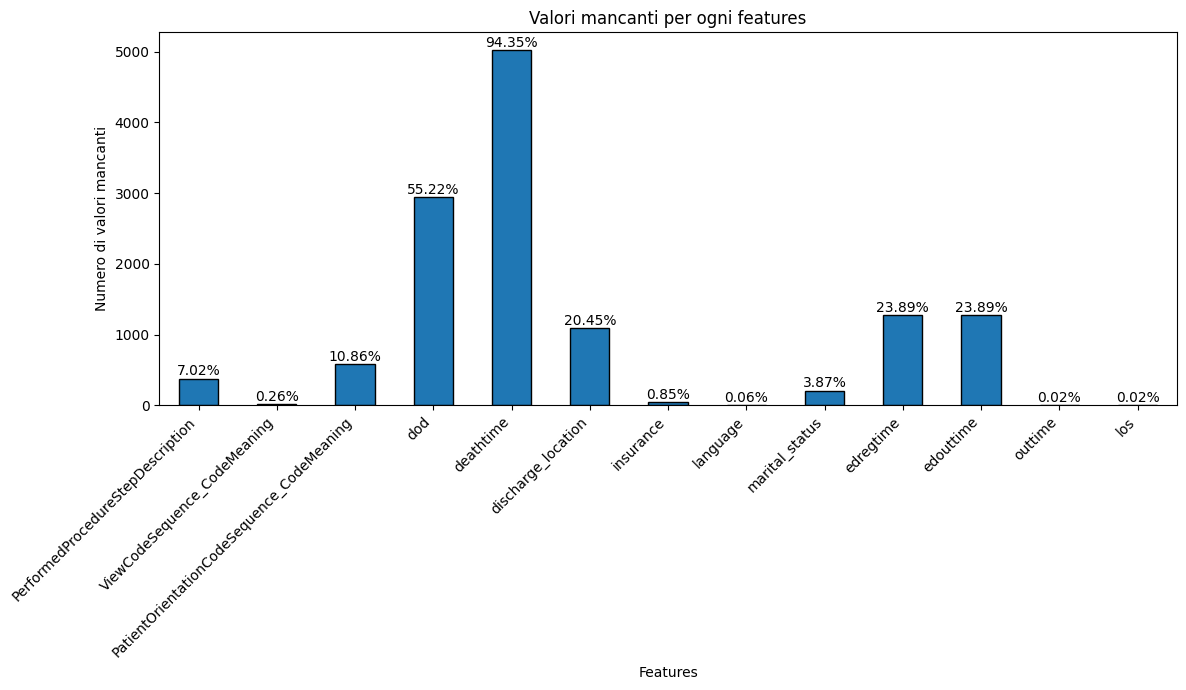

In [23]:
def plot_valori_mancanti(dataset):
    valori_nulli = dataset.isnull().sum()
    valori_nulli = valori_nulli[valori_nulli > 0]
    percentuale = valori_nulli / len(dataset) * 100
    plt.figure(figsize=(12, 7), dpi=100)
    valori_nulli.plot(kind='bar', edgecolor='black')
    for chiave, valore in enumerate(valori_nulli):
        plt.text(chiave, valore + (max(valori_nulli) * 0.01), f"{percentuale.iloc[chiave]:.2f}%", ha='center', fontsize=10)
    plt.title('Valori mancanti per ogni features')
    plt.ylabel('Numero di valori mancanti')
    plt.xlabel('Features')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
        
plot_valori_mancanti(dataset)

Tutti i valori mancanti rappresentano dei dati inutili (eccetto los), perciò procedo con l'eliminazione delle features. Los, invece elimino quei pochissimi record (0,1%), poiché in campo medico è preferibile eliminare le indicisioni (visto la percentuale), piuttosto che generare rumore con l'imputazione.

In [24]:
dataset = dataset.dropna(subset=['los'])

## Gestione dei duplicati

Per prima cosa, si crea una feature unica datetime

In [25]:
dataset['StudyDate_str'] = dataset['StudyDate'].astype(int).astype(str)
dataset['StudyTime_str'] = dataset['StudyTime'].astype(int).astype(str)
dataset['StudyTime_str'] = dataset['StudyTime_str'].str.zfill(6) # HHMMSS
dataset['StudyDateTime'] = pd.to_datetime(
    dataset['StudyDate_str'] + dataset['StudyTime_str'],
    format='%Y%m%d%H%M%S',
    errors='coerce'
)

## Normalizzazione dei dati

Le colonne utili sono subject_id per la primary key, gender, anchor_age, ViewPosition, los, admission_type

In [29]:
colonne_buone = ['subject_id','gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type', 'path_immagine', 'testo_referto' , 'stato_clinico', 'numero_severita']
dataset = dataset[colonne_buone].copy()
print(dataset.columns.tolist())

['subject_id', 'gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type', 'path_immagine', 'testo_referto', 'stato_clinico', 'numero_severita']


In [30]:
dataset.head()

,subject_id,gender,anchor_age,ViewPosition,los,admission_type,path_immagine,testo_referto,stato_clinico,numero_severita
0,11843205,F,46,AP,0.685683,EW EMER.,data/MIMIC_SUPER_RES_24K/b67453f9-6ab4777d-0a6...,FINAL REPORT\...,NEGATIVO,0
1,10952022,M,56,PA,3.892801,OBSERVATION ADMIT,data/MIMIC_SUPER_RES_24K/193055f1-e64091f1-318...,FINAL REPORT\...,TRAUMI,2
2,10637168,F,62,AP,5.048495,EW EMER.,data/MIMIC_SUPER_RES_24K/07235d4a-af51e23b-46d...,FINAL REPORT\...,TRAUMI,2
3,11345335,F,65,AP,1.504641,EW EMER.,data/MIMIC_SUPER_RES_24K/8740ab7e-0b7fc13b-be3...,FINAL REPORT\...,NEGATIVO,0
4,10824358,M,57,PA,1.548125,SURGICAL SAME DAY ADMISSION,data/MIMIC_SUPER_RES_24K/a6ef8e31-ef0b72de-4c9...,FINAL REPORT\...,NEGATIVO,0


In [31]:
colonne_feature = ['gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type']
feature = dataset[colonne_feature].copy()
encoder = LabelEncoder()
feature['gender'] = encoder.fit_transform(feature['gender'])
feature['ViewPosition'] = encoder.fit_transform(feature['ViewPosition'])
feature = pd.get_dummies(feature, columns=['admission_type'], drop_first=True, dtype=float)
feature = feature.astype(float)
feature.head()

,gender,anchor_age,ViewPosition,los,admission_type_DIRECT EMER.,admission_type_DIRECT OBSERVATION,admission_type_ELECTIVE,admission_type_EU OBSERVATION,admission_type_EW EMER.,admission_type_OBSERVATION ADMIT,admission_type_SURGICAL SAME DAY ADMISSION,admission_type_URGENT
0,0.0,46.0,0.0,0.685683,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,56.0,1.0,3.892801,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,62.0,0.0,5.048495,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,65.0,0.0,1.504641,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,57.0,1.0,1.548125,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Matrice di correlazione e calcolo del VIF

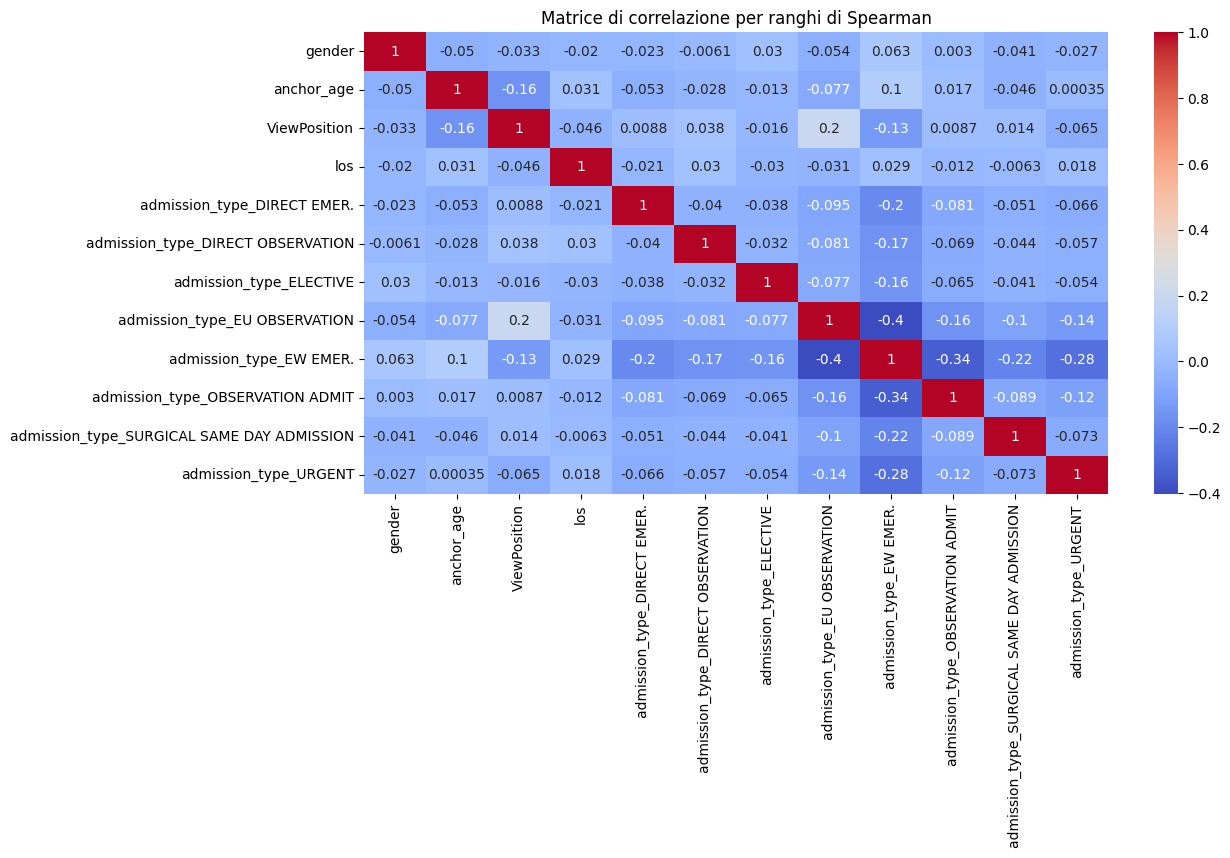

In [32]:
plt.figure(figsize=(12, 6))
plt.title('Matrice di correlazione per ranghi di Spearman')
sns.heatmap(feature.corr(method='spearman'), annot=True, cmap='coolwarm')
plt.show()

In [33]:
vif_data = pd.DataFrame()
vif_data['feature'] = feature.columns
feature_const = sm.add_constant(feature)
vif_data['VIF'] = [variance_inflation_factor(feature_const.values, ind+1) for ind in range(feature.shape[1])]
print(vif_data)

                                       feature        VIF
0                                       gender   1.013877
1                                   anchor_age   1.040756
2                                 ViewPosition   1.075968
3                                          los   1.003805
4                  admission_type_DIRECT EMER.   4.446285
5            admission_type_DIRECT OBSERVATION   3.566033
6                      admission_type_ELECTIVE   3.320764
7                admission_type_EU OBSERVATION  12.040787
8                      admission_type_EW EMER.  20.907876
9             admission_type_OBSERVATION ADMIT   9.738362
10  admission_type_SURGICAL SAME DAY ADMISSION   5.110409
11                       admission_type_URGENT   7.439923


Mapping dei dati

In [34]:
mapping_gender = {'M': 0, 'F': 1}
dataset['gender'] = dataset['gender'].map(mapping_gender)

posizioni_uniche = dataset['ViewPosition'].unique()
mapping_view = {pos: ind for ind, pos in enumerate(posizioni_uniche)}
dataset['ViewPosition'] = dataset['ViewPosition'].map(mapping_view)

ammissioni_uniche = dataset['admission_type'].unique()
mapping_admission = {tipo: ind for ind, tipo in enumerate(ammissioni_uniche)}
dataset['admission_type'] = dataset['admission_type'].map(mapping_admission)

dataset['anchor_age'] = pd.to_numeric(dataset['anchor_age'], errors='coerce').fillna(0).astype(int)
dataset['los'] = pd.to_numeric(dataset['los'], errors='coerce').fillna(0).astype(float)

colonne_mappate = ['gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type']
print("Dtypes dopo la conversione:")
print(dataset[colonne_mappate].dtypes)

# Mostriamo i mapping (salvali per la tesi!)
print("\nMapping ViewPosition:", mapping_view)
print("Mapping AdmissionType:", mapping_admission)

Dtypes dopo la conversione:
gender              int64
anchor_age          int64
ViewPosition        int64
los               float64
admission_type      int64
dtype: object

Mapping ViewPosition: {'AP': 0, 'PA': 1}
Mapping AdmissionType: {'EW EMER.': 0, 'OBSERVATION ADMIT': 1, 'SURGICAL SAME DAY ADMISSION': 2, 'EU OBSERVATION': 3, 'DIRECT OBSERVATION': 4, 'URGENT': 5, 'DIRECT EMER.': 6, 'ELECTIVE': 7, 'AMBULATORY OBSERVATION': 8}


Come si può notare, ogni feature possiede colinearità debole, perciò è del tutto inutile eseguire procedure di riduzione di dimensionalità. Ovviamente, le colonne esplose hanno VIF altissimo, ma è del tutto normale

# Parte 3: Distribuzione dei dati

L'unico dato rilevante per calcolare gli outliers è l'anchor_age, poiché è l'unica variabile continua e può mostrare la demografia dei pazienti. I box-plot sugli altri dati non fornirebbe dati interessanti per il modello. Perciò, il box-plot viene fatto su anchor_age diviso per stadio_clinico, per vedere le fascie di età più colpite.

In [35]:
print(dataset.columns.tolist())

['subject_id', 'gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type', 'path_immagine', 'testo_referto', 'stato_clinico', 'numero_severita']


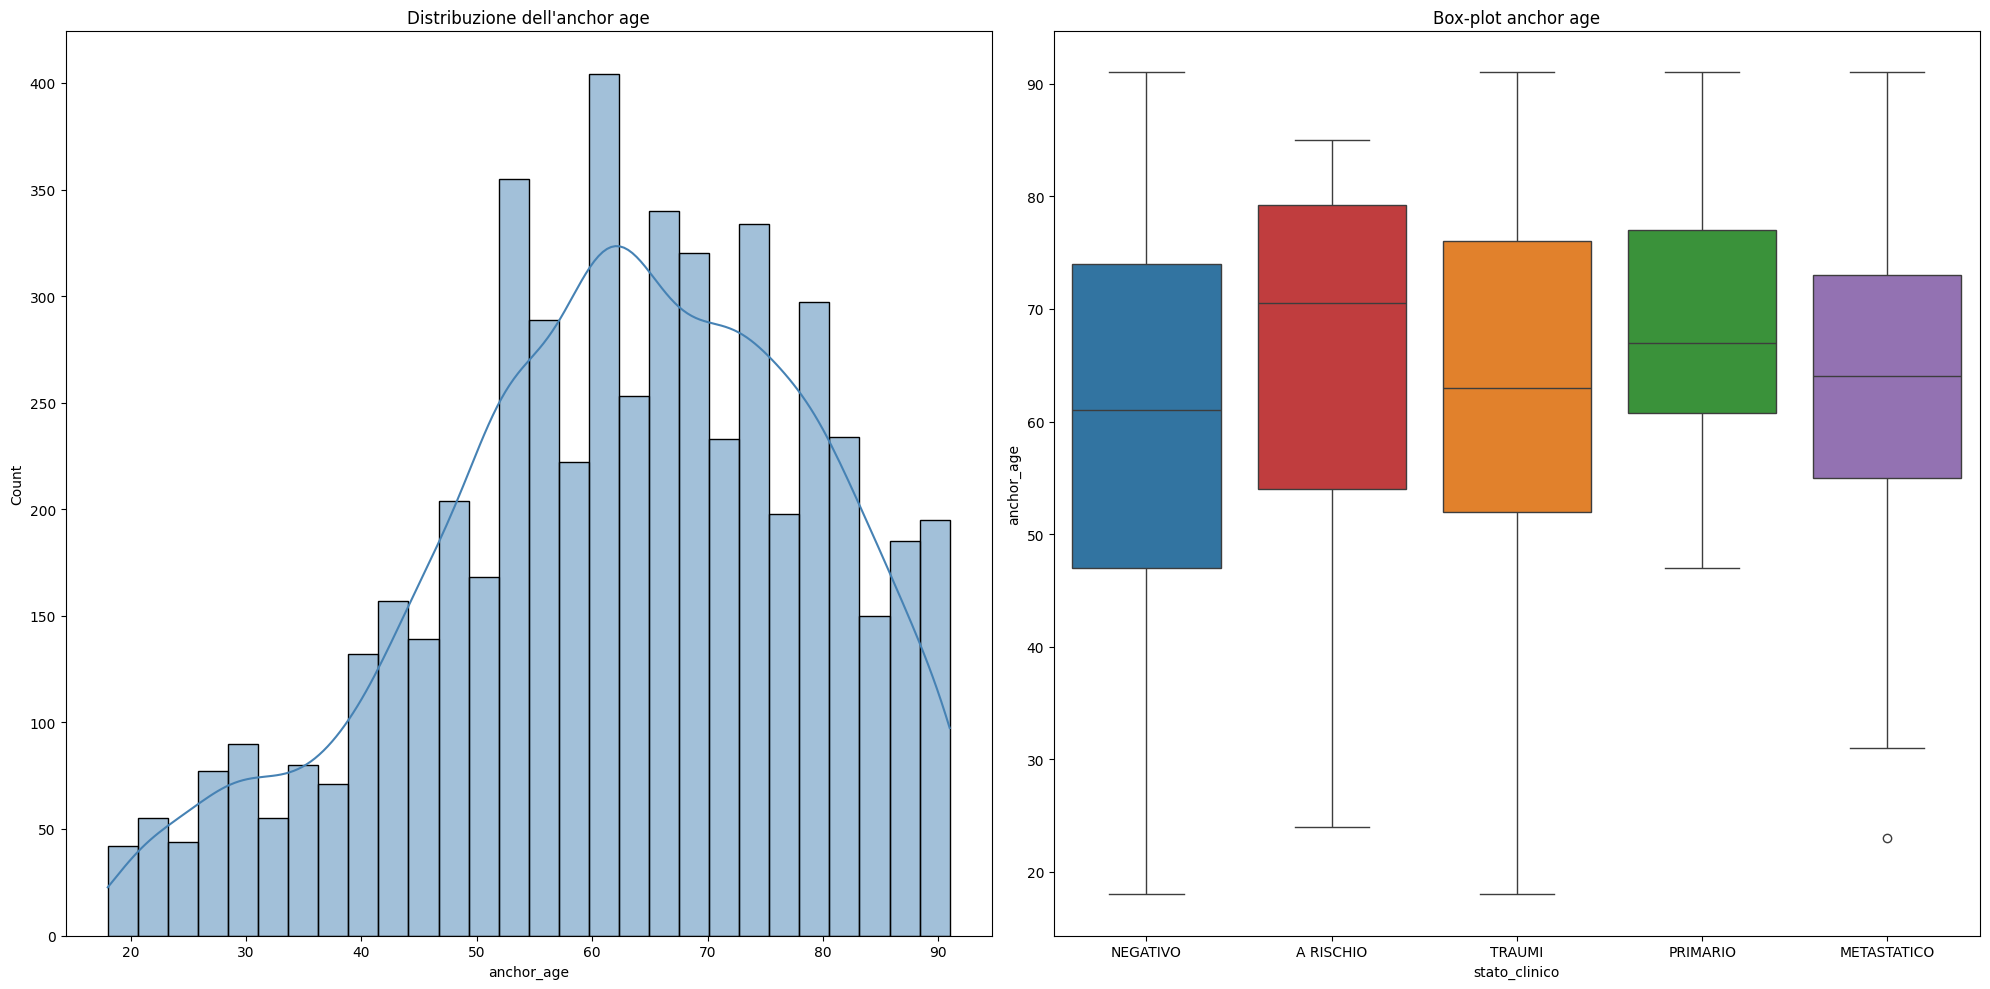

In [36]:
fig, axis = plt.subplots(1, 2, figsize=(20, 10))
ordine_clinico = [
    'NEGATIVO', 
    'A RISCHIO',
    'TRAUMI',
    'PRIMARIO', 
    'METASTATICO'
]
sns.histplot(dataset['anchor_age'], kde=True, ax=axis[0], color='steelblue')
sns.boxplot(x='stato_clinico', y='anchor_age', data=dataset, order=ordine_clinico ,ax=axis[1], hue='stato_clinico', legend=False)
axis[0].set_title("Distribuzione dell'anchor age")
axis[1].set_title("Box-plot anchor age")
plt.tight_layout()
plt.show()

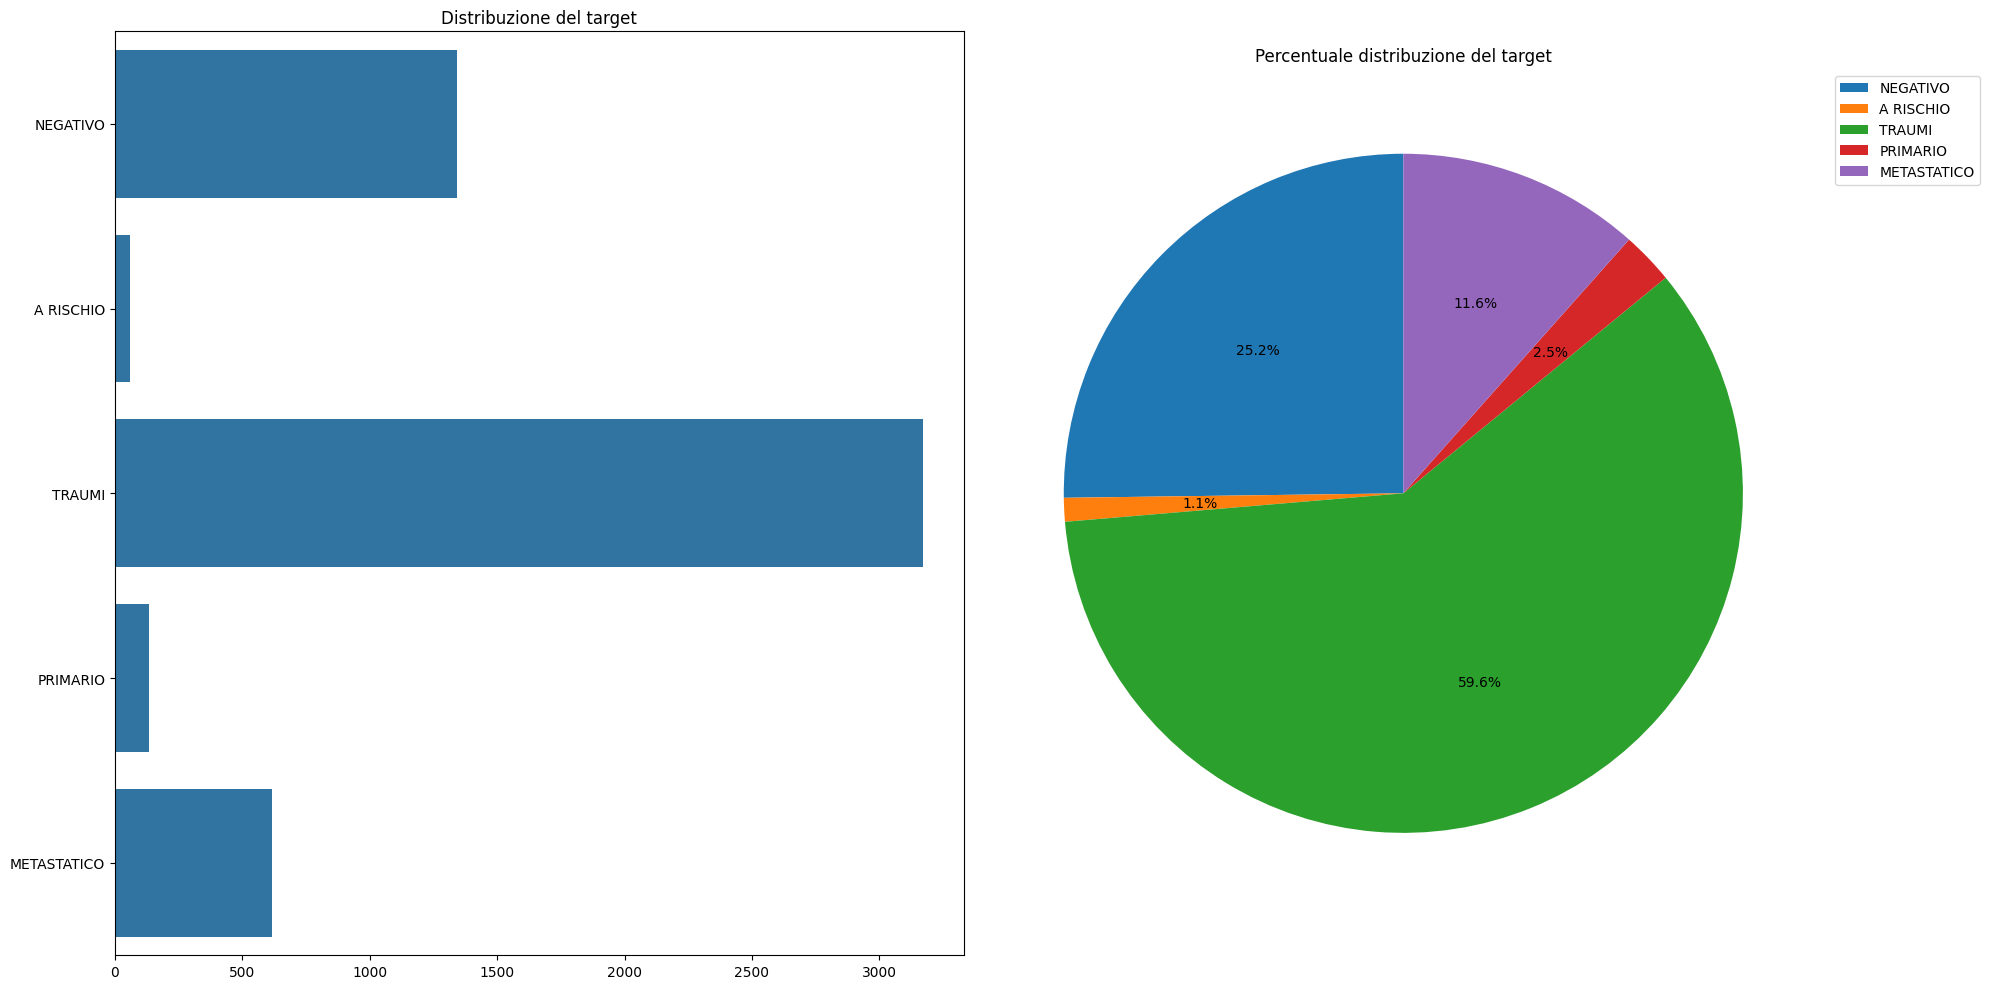

In [37]:
fig, axis = plt.subplots(1, 2, figsize=(20, 10))
target_counts = dataset['stato_clinico'].value_counts().reindex(ordine_clinico).fillna(0)
sns.barplot(x=target_counts.values, y=ordine_clinico, ax=axis[0])
axis[1].pie(target_counts.values, labels=None, autopct='%1.1f%%', startangle=90)
axis[0].set_title("Distribuzione del target")
axis[1].set_title("Percentuale distribuzione del target")
axis[1].legend(labels=ordine_clinico, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Come si può notare, il dataset è molto sbilanciato di casi negativi. Per il momento, escludiamo i negativi.

Come si può notare, il dataset dei positivi risulta leggermente più bilanciato. Perciò, si procede con il data augumentation del I-III stadio, poiché i casi sono veramente rari; e con l'Weighted Cross-Entropy Loss, perché non è presente molta differenza con quelli a rischio. 

In [38]:
dataset_pazienti = dataset[['subject_id', 'numero_severita']].drop_duplicates(subset=['subject_id'])
train_pazienti, temp_pazienti = train_test_split(
    dataset_pazienti,
    test_size = 0.20,
    stratify = dataset_pazienti['numero_severita'],
    random_state = 42
)
val_pazienti, test_pazienti = train_test_split(
    temp_pazienti,
    test_size = 0.50,
    stratify = temp_pazienti['numero_severita'],
    random_state = 42
)
train_set = dataset[dataset['subject_id'].isin(train_pazienti['subject_id'])].copy()
validation_set = dataset[dataset['subject_id'].isin(val_pazienti['subject_id'])].copy()
test_set = dataset[dataset['subject_id'].isin(test_pazienti['subject_id'])].copy()
train_set

,subject_id,gender,anchor_age,ViewPosition,los,admission_type,path_immagine,testo_referto,stato_clinico,numero_severita
0,11843205,1,46,0,0.685683,0,data/MIMIC_SUPER_RES_24K/b67453f9-6ab4777d-0a6...,FINAL REPORT\...,NEGATIVO,0
1,10952022,0,56,1,3.892801,1,data/MIMIC_SUPER_RES_24K/193055f1-e64091f1-318...,FINAL REPORT\...,TRAUMI,2
2,10637168,1,62,0,5.048495,0,data/MIMIC_SUPER_RES_24K/07235d4a-af51e23b-46d...,FINAL REPORT\...,TRAUMI,2
4,10824358,0,57,1,1.548125,2,data/MIMIC_SUPER_RES_24K/a6ef8e31-ef0b72de-4c9...,FINAL REPORT\...,NEGATIVO,0
5,10924501,1,80,0,1.988981,0,data/MIMIC_SUPER_RES_24K/4a1e6a75-fbf2ef42-9e2...,WET READ: ___ ___ ___ 8:35 PM\n Low lung vol...,TRAUMI,2
...,...,...,...,...,...,...,...,...,...,...
5319,10297774,0,62,0,8.070035,0,data/MIMIC_SUPER_RES_24K/08a511d3-edcee26d-126...,FINAL REPORT\...,TRAUMI,2
5320,12232510,0,52,0,1.379815,0,data/MIMIC_SUPER_RES_24K/70b835aa-d7fa8d15-828...,FINAL REPORT\...,TRAUMI,2
5321,11378150,0,71,0,1.667905,0,data/MIMIC_SUPER_RES_24K/7d987f2a-f684bbcb-c1e...,FINAL REPORT\...,METASTATICO,4
5322,10022037,0,61,1,1.712164,0,data/MIMIC_SUPER_RES_24K/19d0a8b9-c301f557-799...,FINAL REPORT\...,NEGATIVO,0


In [39]:
print("--- DISTRIBUZIONE TRAIN SET ---")
print(train_set['stato_clinico'].value_counts())
print(f"\nTotale immagini per l'addestramento: {len(train_set)}")

--- DISTRIBUZIONE TRAIN SET ---
stato_clinico
TRAUMI         2590
NEGATIVO       1068
METASTATICO     494
PRIMARIO         98
A RISCHIO        47
Name: count, dtype: int64

Totale immagini per l'addestramento: 4297


## Data augmentation

In [40]:
base = T.Compose([
    T.Resize((224, 224), interpolation=T.InterpolationMode.BILINEAR), 
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

augmentation = T.Compose([
    T.RandomResizedCrop(224, scale=(0.9, 1.0)), # Simula zoom/distanze diverse
    T.RandomRotation(degrees=7), # Aumentato leggermente a 7 gradi
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)), # Traslazioni leggermente più marcate
    T.ColorJitter(brightness=0.2, contrast=0.2), # Fondamentale per RX: simula diverse esposizioni
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

## Undersampling

Per eseguire l'undersampling, trovo i pazienti sani simili, con la logica degli N-grammi e la Cosine Similarity.

In [41]:
model_st = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
df_traumi = train_set[train_set['stato_clinico'] == 'TRAUMI'].copy()
sentences = df_traumi['testo_referto'].tolist()
embeddings = model_st.encode(sentences, convert_to_tensor=True)
centroid = torch.mean(embeddings, dim=0)
cosine_scores = util.cos_sim(embeddings, centroid).flatten()
top_k_indices = torch.topk(cosine_scores, k=1068).indices.cpu().numpy()
df_traumi_top = df_traumi.iloc[top_k_indices]
altre_classi = train_set[train_set['numero_severita'] != 2]
train_set_sbilanciato = pd.concat([df_traumi_top, altre_classi]).sample(frac=1).reset_index(drop=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [42]:
def bilancia_dataframe_a_1000(df, df_traumi_top):
    target_n = 1068
    nuovi_pezzi = []
    
    for classe in [0, 1, 2, 3, 4]:
        if classe == 2:
            if df_traumi_top is not None and not df_traumi_top.empty:
                nuovi_pezzi.append(df_traumi_top)
        else:
            df_classe = df[df['numero_severita'] == classe]
            
            if not df_classe.empty:
                # Calcoliamo quante volte replicare la classe per arrivare a 1000
                moltiplicatore = (target_n // len(df_classe)) + 1
                df_aug = pd.concat([df_classe] * moltiplicatore, ignore_index=True)
                
                # Tagliamo esattamente a 1000 e aggiungiamo alla lista
                nuovi_pezzi.append(df_aug.iloc[:target_n])
            else:
                print(f"Attenzione: La classe {classe} è vuota nel dataframe di input!")
            
    # Ora la lista nuovi_pezzi contiene 5 dataframe da 1000 righe ciascuno
    return pd.concat(nuovi_pezzi).sample(frac=1).reset_index(drop=True)

# Ora lancia il comando
train_set_bilanciato = bilancia_dataframe_a_1000(train_set, df_traumi_top)

In [43]:
print("--- DISTRIBUZIONE FINALE TRAIN SET ---")
print(train_set_bilanciato['stato_clinico'].value_counts())
print(f"\nTotale immagini per l'addestramento: {len(train_set)}")

--- DISTRIBUZIONE FINALE TRAIN SET ---
stato_clinico
PRIMARIO       1068
NEGATIVO       1068
METASTATICO    1068
A RISCHIO      1068
TRAUMI         1068
Name: count, dtype: int64

Totale immagini per l'addestramento: 4297


## Weighted Cross-Entropy

In [44]:
def calcola_pesi_loss(dataframe, augmentation=True):
    conta = dataframe['numero_severita'].value_counts()
    
    # Conteggi (assumendo Negativo e Traumi a 1000, gli altri originali)
    n0 = 1068  # NEGATIVO
    n1 = conta.get(1, 1) # A RISCHIO (33)
    n2 = 1068 # TRAUMI
    n3 = conta.get(3, 1) # PRIMARIO (88)
    n4 = conta.get(4, 1) # METASTATICO (414)

    if not augmentation:
        # Senza augmentation: pesi alti per compensare lo sbilanciamento
        pesi = [1.0, n0/n1, 1.0, n0/n3, n0/n4]
    else:
        # Con augmentation e oversampling: tutte le classi pesano uguale
        pesi = [1.0, 1.0, 1.0, 1.0, 1.0]
        
    return torch.tensor(pesi, dtype=torch.float32)

Con Augmentation

In [45]:
pesi_aug = calcola_pesi_loss(train_set, augmentation=True)
pesi_baseline = calcola_pesi_loss(train_set, augmentation=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Parte 4: Addestramento e risultati

In [46]:
ricerca_train = os.path.join(os.getcwd())

In [45]:
# Training clinico
feat_cols = ['gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type']
clinical_model = train_modello_clinico(train_set_bilanciato, validation_set, feat_cols)


--- TRAINING MODELLO CLINICO ---
[0]	validation_0-mlogloss:1.60765


[100]	validation_0-mlogloss:1.51175
[200]	validation_0-mlogloss:1.47054
[300]	validation_0-mlogloss:1.43676
[400]	validation_0-mlogloss:1.41949
[499]	validation_0-mlogloss:1.40191


In [46]:
from PIL import Image

# Disabilita il limite di sicurezza per le immagini mediche ad altissima risoluzione
Image.MAX_IMAGE_PIXELS = None

In [47]:
# Training modello visivo con augmentation
modello_aug, hist_aug = train_modello_visivo(
    train_set_bilanciato, 
    validation_set, 
    ricerca_train, 
    base, 
    augmentation, 
    pesi=pesi_aug,
    device=device, 
    use_aug=True
)


--- TRAINING MODELLO VISIVO (AUG) ---


Rilevato checkpoint esistente: last_checkpoint_aug.pth. Ripristino in corso...
Ripresa addestramento dall'epoca 12. Miglior F1 precedente: 0.4900
Ripresa addestramento dall'epoca 11


Epoca 12/30:   0%|          | 0/40 [00:00<?, ?it/s]

[AUG] Ep 12: Loss: 1.2050 | F1: 0.4883 | Acc: 0.5618 | Rec: 0.1899
Checkpoint epoca 12 salvato con successo.


Epoca 13/30:   0%|          | 0/40 [00:00<?, ?it/s]

...

Epoca 29/30:   0%|          | 0/40 [00:00<?, ?it/s]

[AUG] Ep 29: Loss: 0.6752 | F1: 0.4800 | Acc: 0.5804 | Rec: 0.2188
Checkpoint epoca 29 salvato con successo.


Epoca 30/30:   0%|          | 0/40 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x74759680ede0>
Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x74759680ede0>
Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
   

[AUG] Ep 30: Loss: 0.6364 | F1: 0.4892 | Acc: 0.6107 | Rec: 0.2051
Checkpoint epoca 30 salvato con successo.


In [48]:
# Training modello visivo senza augmentation
modello_baseline, hist_baseline = train_modello_visivo(
    train_set_sbilanciato, 
    validation_set, 
    ricerca_train, 
    base, 
    augmentation, 
    pesi=pesi_baseline,
    device=device, 
    use_aug=False
)


--- TRAINING MODELLO VISIVO (NOAUG) ---


Epoca 1/30:   0%|          | 0/19 [00:00<?, ?it/s]

[NOAUG] Ep 1: Loss: 1.6162 | F1: 0.4837 | Acc: 0.6154 | Rec: 0.2289
Nuovo miglior modello NOAUG salvato!
Checkpoint epoca 1 salvato con successo.


Epoca 2/30:   0%|          | 0/19 [00:00<?, ?it/s]

[NOAUG] Ep 2: Loss: 1.5802 | F1: 0.4291 | Acc: 0.3986 | Rec: 0.2468
Checkpoint epoca 2 salvato con successo.


...

Epoca 29/30:   0%|          | 0/19 [00:00<?, ?it/s]

[NOAUG] Ep 29: Loss: 0.6925 | F1: 0.4102 | Acc: 0.3800 | Rec: 0.1689
Checkpoint epoca 29 salvato con successo.


Epoca 30/30:   0%|          | 0/19 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x74759680ede0>
<function _MultiProcessingDataLoaderIter.__del__ at 0x74759680ede0>Exception ignored in: 
Traceback (most recent call last):
Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x74759680ede0>  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
        
self._shutdown_workers()Traceback (most recent call last):
self._shutdown_workers()Exception ignored in: 

  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
  File "/home/z

[NOAUG] Ep 30: Loss: 0.6713 | F1: 0.3932 | Acc: 0.3590 | Rec: 0.1630
Checkpoint epoca 30 salvato con successo.


In [12]:
dataset_test = RXToraceDataset(
    dataframe=test_set, 
    cartella=ricerca_train, 
    transform_base=base, 
    transform_aug=None, 
    is_train=False
)
evaluator = Evaluator(['NEGATIVO', 'A RISCHIO', 'TRAUMI', 'PRIMARIO', 'METASTATICO'])

NameError: name 'test_set' is not defined

In [3]:
evaluator.plot_training_history(
    history=hist_baseline, 
    titolo="Scenario A: Baseline (Dataset Sbilanciato)", 
    nome_file="baseline"
)

NameError: name 'evaluator' is not defined

In [11]:
evaluator.plot_training_history(
    history=hist_aug, 
    titolo="Scenario B: Augmented (Dataset Bilanciato)", 
    nome_file="augmented"
)

NameError: name 'evaluator' is not defined

TypeError: 'DiagnosiVisiva' object is not subscriptable

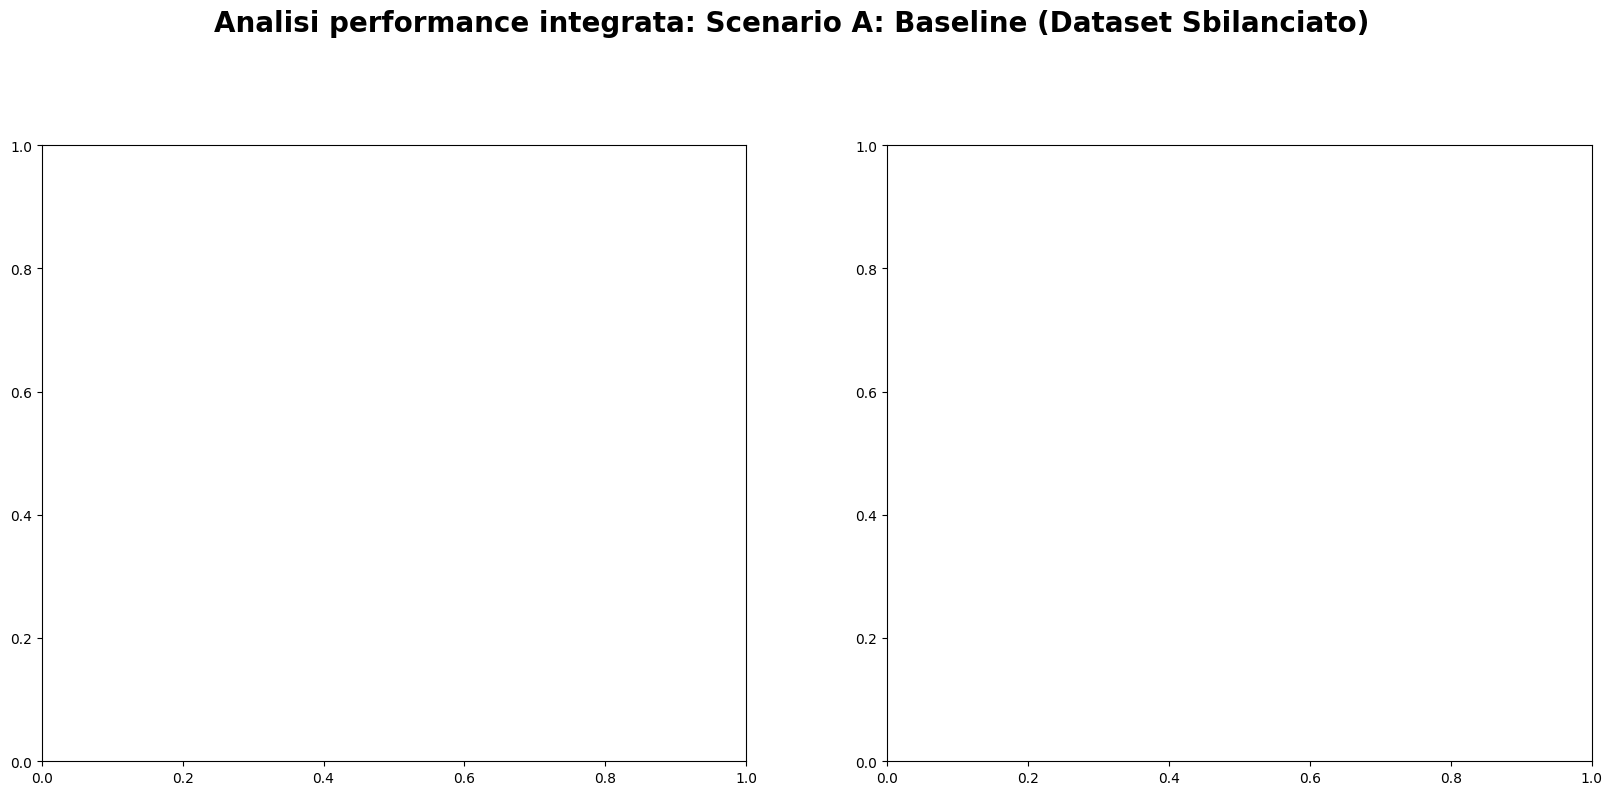

In [67]:
evaluator.plot_scenario_performance(
    res_df=modello_baseline, 
    titolo="Scenario A: Baseline (Dataset Sbilanciato)", 
    nome_file="baseline_gr"
)

In [ ]:
evaluator.plot_scenario_performance(
    res_df=modello_aug, 
    titolo="Scenario B: Augmented (Dataset Bilanciato)", 
    nome_file="augmented_gr"
)